In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('.././data_thuydien/dataCacDap/data_thuydien_Hòa_Bình.csv')
df.head()

,ten_ho,thoi_diem,muc_nuoc_thuong_luu_m,muc_nuoc_dang_binh_thuong_m,muc_nuoc_chet_m,luu_luong_den_ho_m3_s,tong_luong_xa_m3_s,tong_luong_xa_qua_dap_tran_m3_s,tong_luong_xa_qua_nha_may_m3_s,so_cua_xa_sau,so_cua_xa_mat
0,Hòa Bình,2022-01-01 00:00:00,112.13,117,80,848.0,1104.0,0.0,1104.0,0,0
1,Hòa Bình,2022-01-01 01:00:00,112.14,117,80,700.0,589.0,0.0,589.0,0,0
2,Hòa Bình,2022-01-01 02:00:00,112.14,117,80,700.0,589.0,0.0,589.0,0,0
3,Hòa Bình,2022-01-01 03:00:00,112.14,117,80,700.0,589.0,0.0,589.0,0,0
4,Hòa Bình,2022-01-01 04:00:00,112.14,117,80,700.0,589.0,0.0,589.0,0,0


# Step1: Loại bỏ một số cột không cần thiết

In [3]:
cols_to_drop = [
    "muc_nuoc_dang_binh_thuong_m",
    "muc_nuoc_chet_m",
    "so_cua_xa_sau",
    "so_cua_xa_mat",
]

missing = [c for c in cols_to_drop if c not in df.columns]
if missing:
    print("Cột không tìm thấy (bỏ qua khi xoá):", missing)


In [4]:
before_shape = df.shape
before_cols = set(df.columns)

df = df.drop(columns=cols_to_drop, errors="ignore")

after_shape = df.shape
dropped_effective = list(before_cols - set(df.columns))

print("ĐÃ XOÁ:", dropped_effective)
print("Shape trước -> sau:", before_shape, "->", after_shape)
print("Còn lại các cột:", list(df.columns))

df.to_csv(".././data_thuydien_preprocessed/data_thuydien_HoaBinh_preprocessed_step1.csv", index=False, encoding="utf-8")


ĐÃ XOÁ: ['muc_nuoc_chet_m', 'so_cua_xa_mat', 'muc_nuoc_dang_binh_thuong_m', 'so_cua_xa_sau']
Shape trước -> sau: (34343, 11) -> (34343, 7)
Còn lại các cột: ['ten_ho', 'thoi_diem', 'muc_nuoc_thuong_luu_m', 'luu_luong_den_ho_m3_s', 'tong_luong_xa_m3_s', 'tong_luong_xa_qua_dap_tran_m3_s', 'tong_luong_xa_qua_nha_may_m3_s']


# Xử lý

## Xử lý outlier của trường thông tin `muc_nuoc_thuong_luu_m`, chú trọng việc xử lý theo từng tháng

In [5]:
df = pd.read_csv('.././data_thuydien_preprocessed/data_thuydien_HoaBinh_preprocessed_step1.csv')

In [6]:
import pandas as pd
import numpy as np

time_col   = "thoi_diem"
target_col = "muc_nuoc_thuong_luu_m"

# Ép datetime an toàn
df[time_col] = (
    pd.to_datetime(df[time_col], errors="coerce", infer_datetime_format=True)
)

# Thử format cố định nếu còn NaT
if df[time_col].isna().any():
    s2 = pd.to_datetime(df[time_col].astype(str), errors="coerce", format="%Y-%m-%d %H:%M:%S")
    df[time_col] = df[time_col].fillna(s2)

assert df[time_col].notna().all(), "Còn NaT ở thoi_diem — cần làm sạch trước."
df[target_col] = pd.to_numeric(df[target_col], errors="raise")

# Khóa nhóm
df["year"]  = df[time_col].dt.year
df["month"] = df[time_col].dt.month


/tmp/ipykernel_3304221/540051599.py:9: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  pd.to_datetime(df[time_col], errors="coerce", infer_datetime_format=True)


In [7]:
from IPython.display import display

# Chọn phạm vi năm cần xử lý (đổi nếu chỉ muốn 2022–2024)
years_to_fix = sorted(df["year"].unique())   # ví dụ: [2022, 2023, 2024]
mask_years   = df["year"].isin(years_to_fix)

# Làm việc trên subset theo năm cần xử lý
sub = df.loc[mask_years, [time_col, "year", "month", target_col]].copy()

# Tính Q1/Q3 theo (year, month)
gb = sub.groupby(["year","month"])[target_col]
sub["Q1"] = gb.transform(lambda s: s.quantile(0.25))
sub["Q3"] = gb.transform(lambda s: s.quantile(0.75))
sub["IQR"] = sub["Q3"] - sub["Q1"]
sub["LB"]  = sub["Q1"] - 1.5*sub["IQR"]
sub["UB"]  = sub["Q3"] + 1.5*sub["IQR"]

# Đánh dấu outlier theo (year, month)
sub["is_out"] = (sub[target_col] < sub["LB"]) | (sub[target_col] > sub["UB"])

# Tóm tắt theo (year, month)
month_summary = (sub.groupby(["year","month"], as_index=False)
                   .agg(n=(target_col, "size"),
                        n_out=("is_out", "sum"),
                        LB=("LB", "first"),
                        UB=("UB", "first"))
                   .sort_values(["year","month"]))
display(month_summary)

# Các (năm, tháng) cần xử lý (có ít nhất 1 outlier)
pairs_to_fix = set(map(tuple, month_summary.loc[month_summary["n_out"]>0, ["year","month"]].values.tolist()))
print("Các (năm, tháng) sẽ được xử lý:", sorted(pairs_to_fix))


,year,month,n,n_out,LB,UB
0,2022,1,744,0,97.98500,119.38500
1,2022,2,672,0,104.03000,107.79000
2,2022,3,744,0,106.67000,108.35000
3,2022,4,720,0,105.27000,108.15000
4,2022,5,744,0,99.04125,111.89125
5,2022,6,720,0,101.90375,111.59375
6,2022,7,744,0,95.16125,112.01125
7,2022,8,744,19,95.42625,103.43625
8,2022,9,720,0,97.59500,118.67500
9,2022,10,744,107,114.53500,116.41500


Các (năm, tháng) sẽ được xử lý: [(2022, 8), (2022, 10), (2023, 1), (2023, 2), (2023, 7), (2023, 9), (2024, 4), (2024, 10), (2025, 10), (2025, 11)]


In [8]:
# Cờ "tháng–năm thuộc danh sách cần xử lý"
apply_mask = sub[["year","month"]].apply(tuple, axis=1).isin(pairs_to_fix)

# Mask outlier cần fill
mask_out = apply_mask & ((sub[target_col] < sub["LB"]) | (sub[target_col] > sub["UB"]))

# Fill: <LB -> LB, >UB -> UB (theo từng hàng, đã có LB/UB riêng của (year,month))
filled = sub[target_col].where(sub[target_col] >= sub["LB"], sub["LB"])
filled = filled.where(filled <= sub["UB"], sub["UB"])
sub["filled"] = sub[target_col]
sub.loc[mask_out, "filled"] = filled.loc[mask_out]

# Gộp về df gốc theo index
df["muc_nuoc_thuong_luu_m_filled"] = df[target_col]
df.loc[sub.index, "muc_nuoc_thuong_luu_m_filled"] = sub["filled"].values

# Kiểm chứng sau fill: còn ai vượt LB/UB trong các (năm,tháng) đã xử lý?
chk = sub.copy()
chk["after"] = chk["filled"]
viol = chk[apply_mask & ((chk["after"] < chk["LB"]) | (chk["after"] > chk["UB"]))]
print("Số điểm còn vi phạm sau fill (kỳ vọng 0):", len(viol))

# Thống kê số điểm đã fill theo (year, month)
changed = (sub["filled"] != sub[target_col])
cap_stats = (pd.DataFrame({"year": sub["year"], "month": sub["month"], "changed": changed})
             .groupby(["year","month"], as_index=False)
             .agg(changed=("changed","sum")))
cap_stats = cap_stats.merge(month_summary[["year","month","n"]], on=["year","month"], how="left")
cap_stats["changed_pct"] = (100.0 * cap_stats["changed"] / cap_stats["n"]).round(2)
display(cap_stats.sort_values(["year","month"]))
print("Tổng số điểm đã fill:", int(cap_stats["changed"].sum()))


Số điểm còn vi phạm sau fill (kỳ vọng 0): 0


,year,month,changed,n,changed_pct
0,2022,1,0,744,0.00
1,2022,2,0,672,0.00
2,2022,3,0,744,0.00
3,2022,4,0,720,0.00
4,2022,5,0,744,0.00
5,2022,6,0,720,0.00
6,2022,7,0,744,0.00
7,2022,8,19,744,2.55
8,2022,9,0,720,0.00
9,2022,10,107,744,14.38


Tổng số điểm đã fill: 411


In [9]:
from pathlib import Path

OUT_PATH = Path(".././data_thuydien_preprocessed/data_thuydien_HoaBinh_preprocessed_step2.csv")
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df_out = df.drop(columns=["year","month"])  # gọn
df_out.to_csv(OUT_PATH, index=False, encoding="utf-8")
print("✅ Đã lưu:", OUT_PATH.resolve())


✅ Đã lưu: /home/uit2023/LuuTru/Thanhld/CS313-DoAn/CuoiKi/data_thuydien_preprocessed/data_thuydien_HoaBinh_preprocessed_step2.csv


Kiểm tra sau khi xử lý

out_dir = "./data_thuydien/plots_preprocessed/"

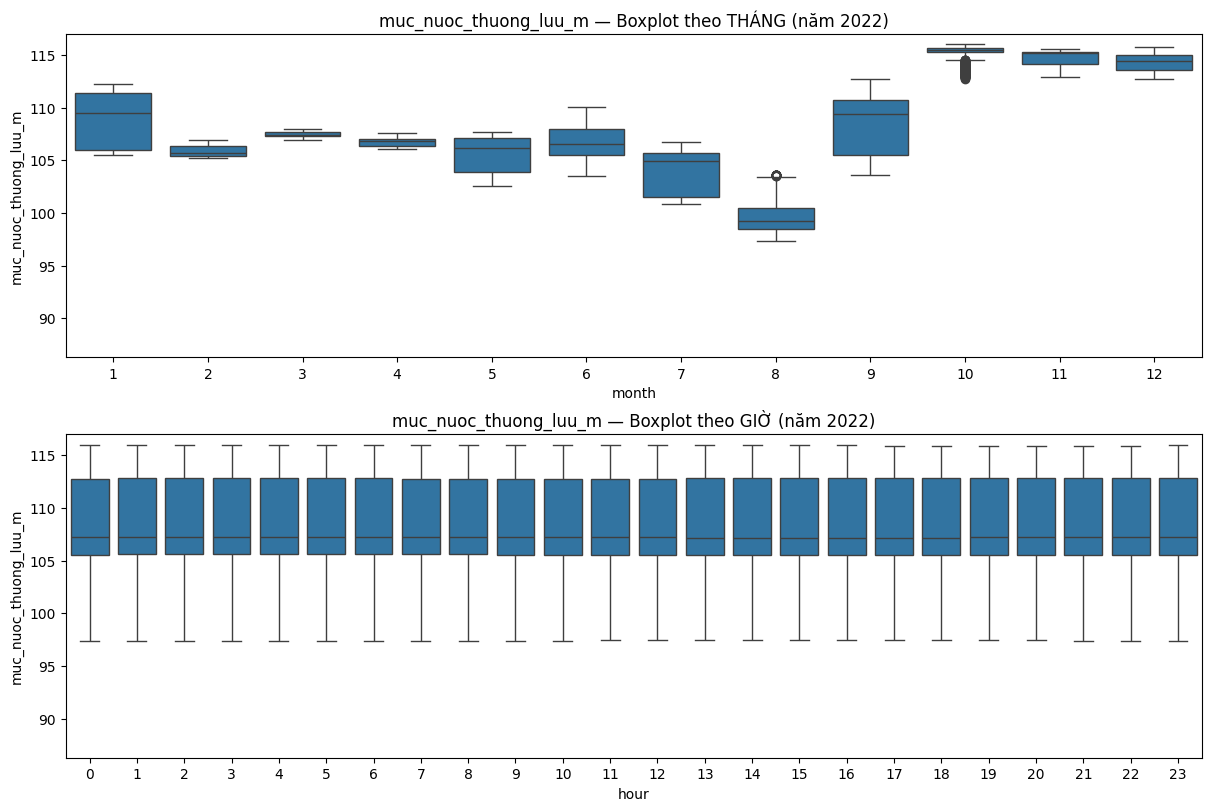

Saved: ./plots_preprocessed/muc_nuoc_thuong_luu_m_box_month_hour_2022.png


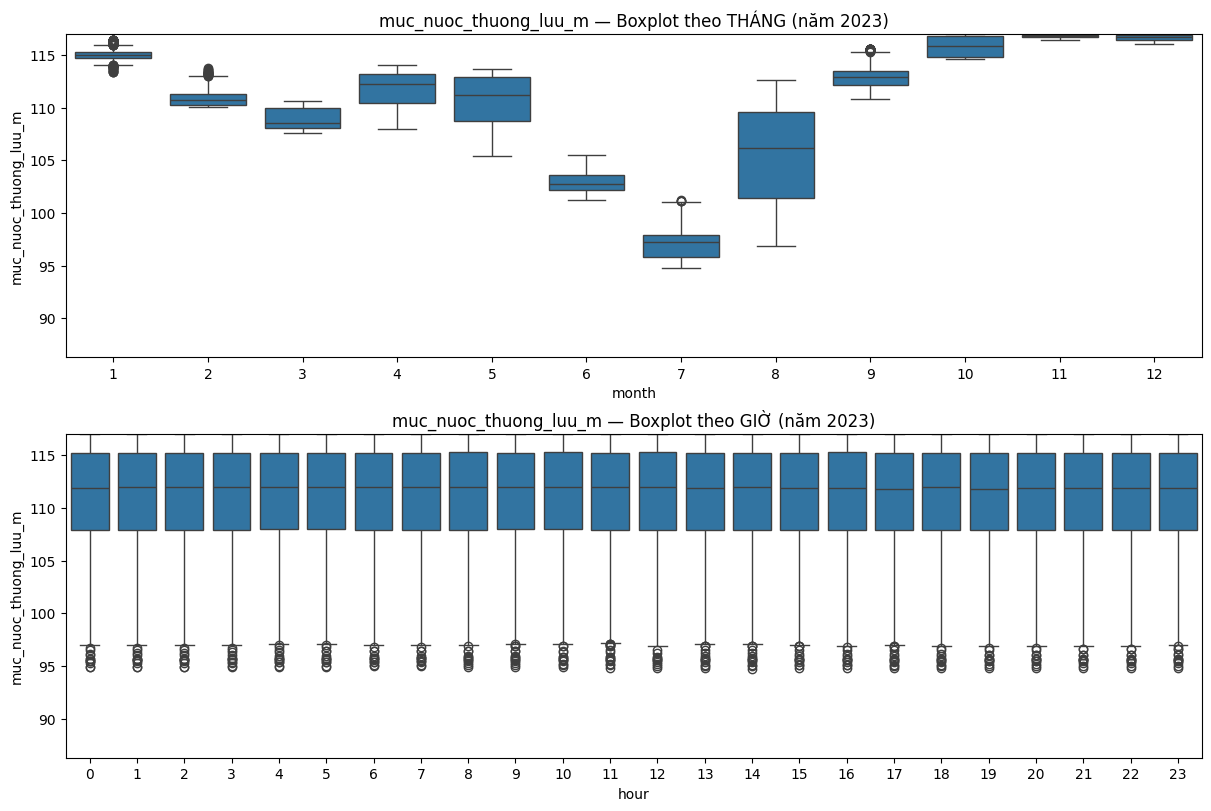

Saved: ./plots_preprocessed/muc_nuoc_thuong_luu_m_box_month_hour_2023.png


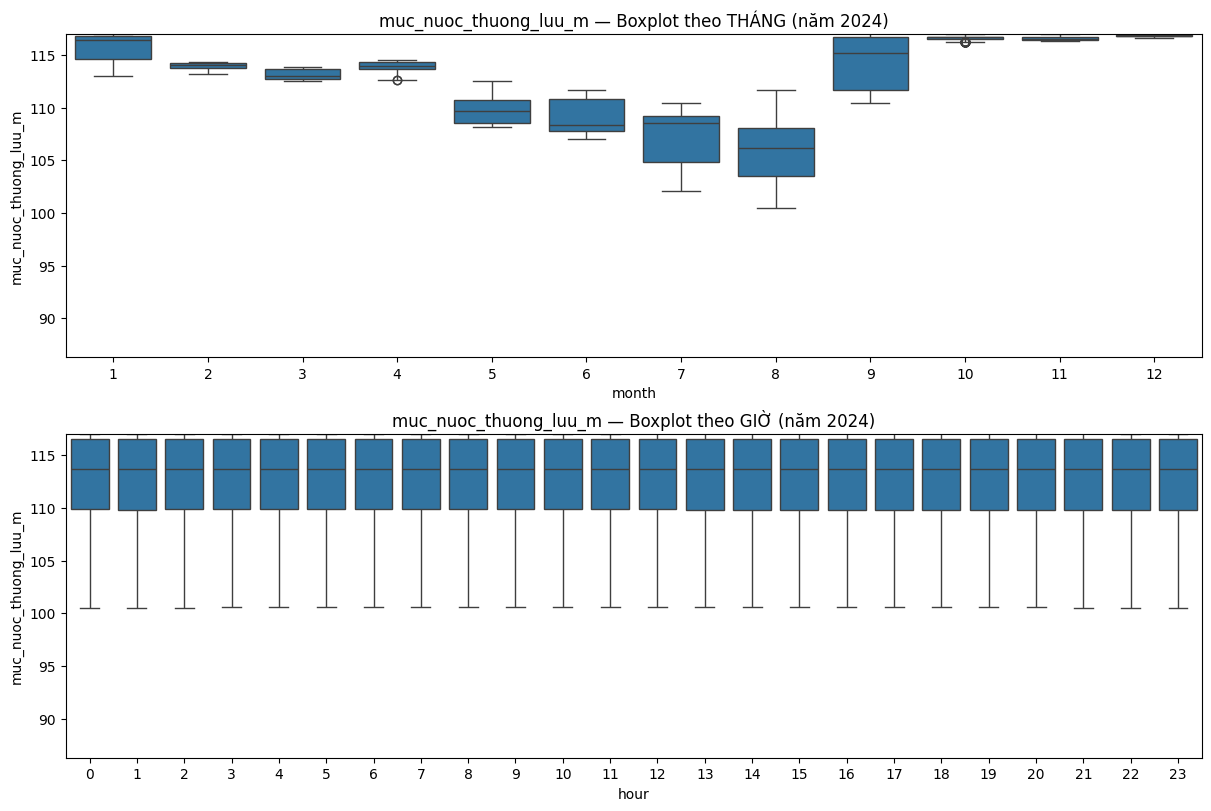

Saved: ./plots_preprocessed/muc_nuoc_thuong_luu_m_box_month_hour_2024.png


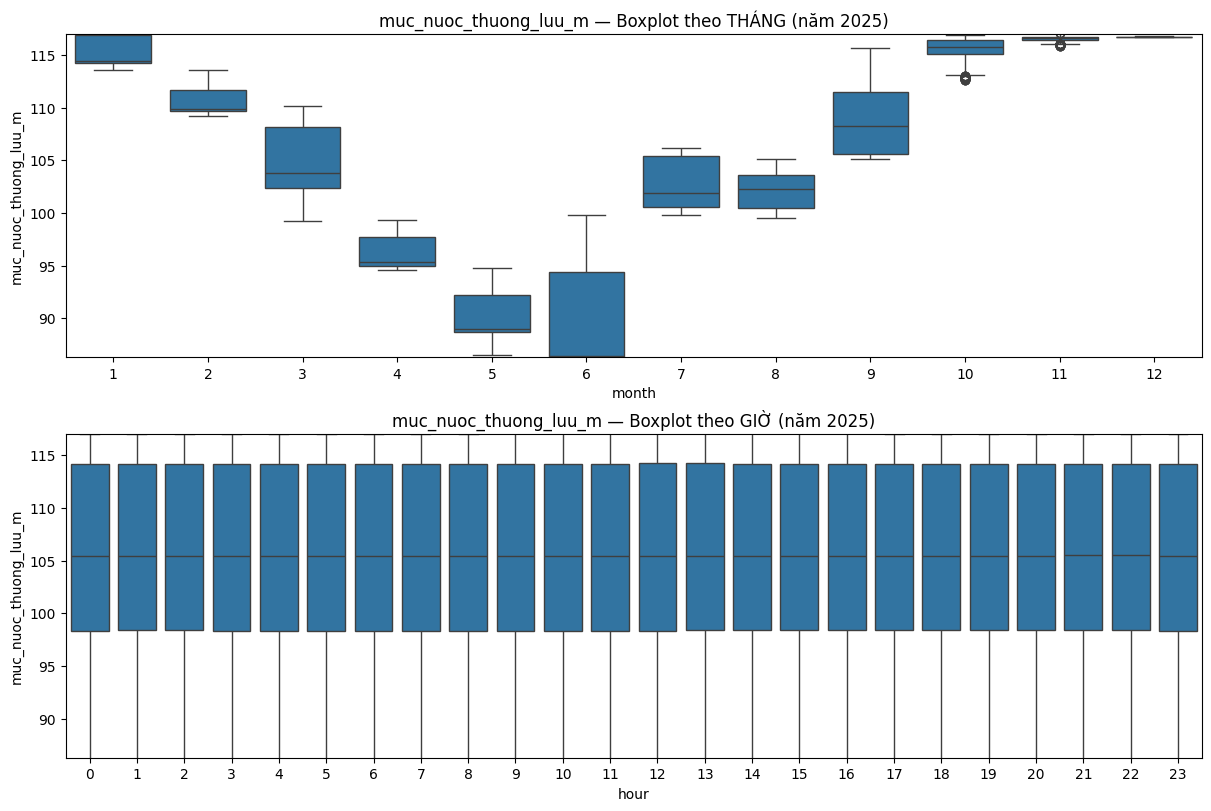

Saved: ./plots_preprocessed/muc_nuoc_thuong_luu_m_box_month_hour_2025.png


In [10]:
import os
import seaborn as sns
import matplotlib.pyplot as plt

df_out = pd.read_csv(".././data_thuydien_preprocessed/data_thuydien_HoaBinh_preprocessed_step2.csv")
# Thư mục lưu ảnh
out_dir = "./plots_preprocessed/"
os.makedirs(out_dir, exist_ok=True)

target = "muc_nuoc_thuong_luu_m"

# ==== Chuẩn bị ====
df_b = df_out.copy()

# Bảo đảm có cột year/month/hour
if 'year' not in df_b:
    df_b['year'] = pd.to_datetime(df_b['thoi_diem'], errors='coerce').dt.year
if 'month' not in df_b:
    df_b['month'] = pd.to_datetime(df_b['thoi_diem'], errors='coerce').dt.month
if 'hour' not in df_b:
    df_b['hour'] = pd.to_datetime(df_b['thoi_diem'], errors='coerce').dt.hour

order_month = list(range(1, 13))
order_hour = list(range(0, 24))

# Cố định trục Y để so sánh giữa các năm công bằng (dùng 1%–99% để tránh outlier cực đoan)
ymin = float(df_b[target].quantile(0.01))
ymax = float(df_b[target].quantile(0.99))
if not np.isfinite(ymin) or not np.isfinite(ymax) or ymin >= ymax:
    ymin = float(df_b[target].min())
    ymax = float(df_b[target].max())

# Thư mục xuất
if 'out_dir' not in globals():
    out_dir = "./data_thuydien/plots_thuydien"
os.makedirs(out_dir, exist_ok=True)

# ==== Vẽ vòng lặp theo năm ====
years = sorted([int(y) for y in df_b['year'].dropna().unique()])

for y in years:
    sub = df_b[df_b['year'] == y].copy()
    if sub.empty:
        continue

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), constrained_layout=True)

    # Boxplot theo tháng (năm y)
    sns.boxplot(x='month', y=target, data=sub, order=order_month, ax=axes[0])
    axes[0].set_title(f'{target} — Boxplot theo THÁNG (năm {y})')
    axes[0].set_xlabel('month'); axes[0].set_ylabel(target)
    axes[0].set_ylim(ymin, ymax)

    # Boxplot theo giờ (năm y)
    sns.boxplot(x='hour', y=target, data=sub, order=order_hour, ax=axes[1])
    axes[1].set_title(f'{target} — Boxplot theo GIỜ (năm {y})')
    axes[1].set_xlabel('hour'); axes[1].set_ylabel(target)
    axes[1].set_ylim(ymin, ymax)

    fn = os.path.join(out_dir, f"{target}_box_month_hour_{y}.png")
    fig.savefig(fn, dpi=150, bbox_inches='tight'); plt.show(); plt.close()
    print("Saved:", fn)


1) Vì sao 2023 vẫn “đầy chấm outlier” theo GIỜ dù bạn đã cap theo THÁNG?

Ngắn gọn: đó là outlier do cấu trúc (structural) chứ không phải lỗi đo/nhập. Cụ thể:

Quy trình vận hành hồ Hòa Bình theo mùa lũ buộc hồ phải hạ mực nước vào tháng 6–8 để dành dung tích chống lũ (giai đoạn “lũ sớm” và “lũ chính vụ”). Văn bản và báo chí nêu rõ trần vận hành: lũ chính vụ không vượt ~101 m, và trước lũ sớm giữ thấp hơn (~105 m), sau 16/9 mới dần tích lên MNDNT 117 m. Những giới hạn này làm phân phối mực nước đa chế độ theo tháng, nên khi bạn vẽ boxplot theo giờ (gộp cả năm), các điểm của tháng 6–8 tự nhiên rơi xuống “đuôi dưới” của phân phối theo giờ và bị vẽ thành outlier—even sau khi đã cap theo tháng. 
TUOI TRE ONLINE
+1

Năm 2023 có nền thủy văn kém do El Niño (thiếu mưa Bắc Bộ/ĐNA). Vì nền mực nước thấp ngay từ đầu mùa mưa, phần điểm theo giờ trong 6–8/2023 càng lệch xuống và bị coi là outlier khi so với các tháng 10–12/2023 (mực nước cao). Đây vẫn là khác biệt mùa–vận hành, không phải noise. 
World Meteorological Organization
+2
reliefweb.int
+2

Vận hành điều tiết ngày (daily peaking) của bậc thang thủy điện cũng tạo dao động mực nước theo ngày/giờ; tài liệu nghiên cứu chỉ ra hiện tượng dao động mực nước ngày (WLF) do vận hành các nhà máy trong chuỗi. Điều này làm đuôi theo giờ “dài” hơn, càng dễ bị vẽ thành outlier. 
MDPI
+1

2) Vì sao 2025 giảm sâu “sớm” từ tháng 5 và chạm đáy tháng 6?

Có 2 yếu tố dễ gây shift thời điểm/hình dạng đường mực nước:

Thay đổi quy định vận hành 2025: Tháng 5/2025 Chính phủ ban hành Quyết định 922/QĐ-TTg sửa đổi/bổ sung Quy trình 740/QĐ-TTg (liên hồ sông Hồng), trong đó nhấn mạnh các quy định vận hành bổ sung cho thời kỳ chuyển tiếp/tích nước và điều kiện lũ bất thường. Thay đổi khung vận hành có thể làm hồ hạ trước/giữ thấp lâu hơn để bảo đảm an toàn và dung tích đón lũ—dễ nhìn như “giảm sớm” từ 5–6/2025. 
Phòng Chống Thiên Tai
+2
Văn Bản Chính Phủ
+2

Mưa/bão lệch pha cuối mùa 2025: Cuối 9/2025 miền Bắc chịu tác động của bão Ragasa/Bualoi với mưa rất lớn (Hà Nội và nhiều tỉnh ngập), trong khi trước đó các tháng đầu mùa mưa mưa yếu hơn—dẫn đến ít nước đầu mùa (5–6) rồi dồn mưa muộn (cuối 9–10) đúng như bạn thấy ở chuỗi mưa. 
AP News
+2
Reuters
+2

Tóm lại: 2025 có thể vừa đổi “chế độ vận hành” (922/2025), vừa lệch pha mưa (bão muộn), nên đường mực nước giảm sớm và sâu từ 5–6, rồi phục hồi mạnh muộn hơn.

## Xử lý trường thông tin `luu_luong_den_ho_m3_s`

In [11]:
import pandas as pd, numpy as np, unicodedata, re
from pathlib import Path

IN_FILE = Path(".././data_thuydien_preprocessed/data_thuydien_HoaBinh_preprocessed_step2.csv")
TARGET  = "luu_luong_den_ho_m3_s"   # tên bạn kỳ vọng

df = pd.read_csv(IN_FILE, encoding="utf-8-sig")  # bóc BOM nếu có

def show_cols(label, cols):
    print(f"\n[{label}] n={len(cols)}")
    for c in cols:
        print(f"- {repr(c)} | esc={c.encode('unicode_escape')}")

show_cols("df.columns (raw)", list(df.columns))

# 1) Coi thử đây có phải MultiIndex columns không
print("\nIs MultiIndex columns? ->", isinstance(df.columns, pd.MultiIndex))
if isinstance(df.columns, pd.MultiIndex):
    # flatten để đảm bảo chọn cột bằng chuỗi đơn
    df.columns = ["__".join(map(str, c)).strip("_") for c in df.columns.to_list()]
    print("Flattened MultiIndex columns.")
    show_cols("df.columns (flattened)", list(df.columns))

# 2) Normalize unicode/space ẩn (NBSP, zero-width)
def norm(s: str) -> str:
    s = unicodedata.normalize("NFKC", s)         # chuẩn hoá
    s = s.replace("\xa0"," ").replace("\u200b","") # nbsp, zero-width
    s = re.sub(r"\s+", " ", s).strip()
    return s

df.rename(columns=lambda x: norm(str(x)), inplace=True)
show_cols("df.columns (unicode-normalized)", list(df.columns))

# 3) Cột có bị đẩy sang index không?
print("\nIndex names:", df.index.names)
if TARGET in (df.index.names or []):
    print(f"--> '{TARGET}' đang là INDEX. Reset lại.")
    df = df.reset_index()

# 4) Cột trùng tên?
dupes = df.columns[df.columns.duplicated()].unique().tolist()
print("\nDuplicated column names:", dupes)

# 5) Kiểm tra tồn tại TRƯỚC & SAU các bước
print(f"\n`{TARGET}` in df.columns? ->", TARGET in df.columns)

# Gợi ý cột tương tự (kể cả khác chút ký tự)
cands = [c for c in df.columns if ("luu" in c.lower() and "luong" in c.lower() and "den" in c.lower())]
print("\nCandidates (token match luu/luong/den):", cands)

# 6) Lưu ra file tạm sau khi flatten/normalize để Cell B dùng
TMP = Path(".././data_thuydien_preprocessed/data_thuydien_HoaBinh_preprocessed_step3.csv")
TMP.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(TMP, index=False, encoding="utf-8")
print("\nSaved diagnostic-normalized file ->", TMP.as_posix())



[df.columns (raw)] n=8
- 'ten_ho' | esc=b'ten_ho'
- 'thoi_diem' | esc=b'thoi_diem'
- 'muc_nuoc_thuong_luu_m' | esc=b'muc_nuoc_thuong_luu_m'
- 'luu_luong_den_ho_m3_s' | esc=b'luu_luong_den_ho_m3_s'
- 'tong_luong_xa_m3_s' | esc=b'tong_luong_xa_m3_s'
- 'tong_luong_xa_qua_dap_tran_m3_s' | esc=b'tong_luong_xa_qua_dap_tran_m3_s'
- 'tong_luong_xa_qua_nha_may_m3_s' | esc=b'tong_luong_xa_qua_nha_may_m3_s'
- 'muc_nuoc_thuong_luu_m_filled' | esc=b'muc_nuoc_thuong_luu_m_filled'

Is MultiIndex columns? -> False

[df.columns (unicode-normalized)] n=8
- 'ten_ho' | esc=b'ten_ho'
- 'thoi_diem' | esc=b'thoi_diem'
- 'muc_nuoc_thuong_luu_m' | esc=b'muc_nuoc_thuong_luu_m'
- 'luu_luong_den_ho_m3_s' | esc=b'luu_luong_den_ho_m3_s'
- 'tong_luong_xa_m3_s' | esc=b'tong_luong_xa_m3_s'
- 'tong_luong_xa_qua_dap_tran_m3_s' | esc=b'tong_luong_xa_qua_dap_tran_m3_s'
- 'tong_luong_xa_qua_nha_may_m3_s' | esc=b'tong_luong_xa_qua_nha_may_m3_s'
- 'muc_nuoc_thuong_luu_m_filled' | esc=b'muc_nuoc_thuong_luu_m_filled'

Index n

In [12]:
import pandas as pd
import numpy as np
import unicodedata, re
from pathlib import Path

# ========= CẤU HÌNH =========
IN_FILE  = Path(".././data_thuydien_preprocessed/data_thuydien_HoaBinh_preprocessed_step3.csv")
OUT_FILE = Path(".././data_thuydien_preprocessed/data_thuydien_HoaBinh_preprocessed_step4.csv")
TIME_COL = "thoi_diem"          # nếu dataset dùng 'time', code sẽ tự fallback
FLOW_EXPECTED = "luu_luong_den_ho_m3_s"
KEEP_DIAGNOSTICS = True         # đặt False nếu không muốn giữ cột chẩn đoán (is_event_month, lb_m, ub_m, ...)

# ========= HÀM PHỤ =========
def _norm_text(s: str) -> str:
    """Chuẩn Unicode (NFKC), bỏ NBSP/zero-width, co khoảng trắng về 1."""
    s = unicodedata.normalize("NFKC", s)
    s = s.replace("\xa0"," ").replace("\u200b","")
    s = re.sub(r"\s+", " ", s).strip()
    return s

def pick_flow_col(df_columns, expected=FLOW_EXPECTED):
    """
    Tìm tên cột lưu lượng đúng 'bản gốc' mà không đổi tên cột trong DataFrame.
    Ưu tiên khớp chính xác; nếu khác ký tự (³, ₃, khoảng trắng ẩn...), dùng so khớp mềm.
    """
    cols = list(df_columns)
    # 1) khớp trực tiếp
    if expected in cols:
        return expected
    # 2) khớp sau normalize
    norm_map = {c: _norm_text(c).lower() for c in cols}
    norm_target = _norm_text(expected).lower()
    # ưu tiên cột có đầy đủ từ khóa
    tokens = ["luu", "luong", "den", "ho"]
    def score(name):
        low = norm_map[name]
        return sum(t in low for t in tokens) + (1 if ("m3" in low or "m_3" in low) else 0)
    cand = sorted(cols, key=score, reverse=True)
    if cand and score(cand[0]) > 0:
        return cand[0]
    return None

# ========= 0) ĐỌC & CHUẨN BỊ =========
if not IN_FILE.exists():
    raise FileNotFoundError(f"Không thấy file: {IN_FILE}")

df = pd.read_csv(IN_FILE, encoding="utf-8-sig")

# Bảo đảm cột thời gian
if TIME_COL not in df.columns:
    if "time" in df.columns:
        TIME_COL = "time"
    else:
        raise KeyError("Không thấy cột thời gian 'thoi_diem' hoặc 'time'.")

# Ép datetime, bỏ tz (nếu có), sort
t = pd.to_datetime(df[TIME_COL], errors="coerce")
if t.notna().mean() < 0.95:
    t = pd.to_datetime(df[TIME_COL], errors="coerce", dayfirst=True)
try:
    t = t.dt.tz_localize(None)
except Exception:
    pass
df[TIME_COL] = t
df = df.dropna(subset=[TIME_COL]).sort_values(TIME_COL).reset_index(drop=True)

# Tìm đúng tên cột lưu lượng trong DF (không đổi tên cột hiện có)
flow_col = pick_flow_col(df.columns, FLOW_EXPECTED)
if not flow_col:
    raise KeyError("Không tìm thấy cột lưu lượng (ví dụ 'luu_luong_den_ho_m3_s'). Kiểm tra header file step 3.")

# Chuẩn numeric, không âm
df[flow_col] = pd.to_numeric(df[flow_col], errors="coerce").clip(lower=0)

# Dùng cột phụ _y/_m để groupby, không đụng đến 'year'/'month' sẵn có
_y = df[TIME_COL].dt.year
_m = df[TIME_COL].dt.month
df["_y_tmp"] = _y
df["_m_tmp"] = _m

# ========= 1) PREPROCESSING (capping thông minh theo (năm,tháng) + tháng sự kiện) =========
# 1.1 Median theo (y,m) & "khí hậu tháng"
mstats = (
    df.groupby(["_y_tmp","_m_tmp"], as_index=False)[flow_col]
      .agg(median="median", count="size")
      .rename(columns={"_y_tmp":"year","_m_tmp":"month"})
)
clim_median = mstats.groupby("month")["median"].median().rename("clim_median")
clim_iqr    = mstats.groupby("month")["median"].agg(lambda s: np.percentile(s,75)-np.percentile(s,25)).rename("clim_iqr")
mstats = mstats.merge(clim_median, on="month", how="left").merge(clim_iqr, on="month", how="left")
mstats["anom_iqr_units"] = (mstats["median"] - mstats["clim_median"]) / mstats["clim_iqr"].replace(0, np.nan)

# 1.2 Δ% giữa các tháng trong năm
m_pivot = mstats.pivot(index="year", columns="month", values="median").sort_index(axis=1)
m_chg   = m_pivot.pct_change(axis=1) * 100.0
chg_long = m_chg.reset_index().melt("year", var_name="month", value_name="pct_change")
chg_long["month"] = chg_long["month"].astype("int64")

# 1.3 LB/UB (IQR1.5) để ước lượng outlier% (cột phẳng bằng quantile+unstack)
q = df.groupby(["_y_tmp","_m_tmp"])[flow_col].quantile([0.25,0.75]).unstack()
q.columns = ["q1","q3"]
q["iqr"] = q["q3"] - q["q1"]
q["lb"]  = (q["q1"] - 1.5*q["iqr"]).clip(lower=0)
q["ub"]  =  q["q3"] + 1.5*q["iqr"]
bounds15 = q.reset_index().rename(columns={"_y_tmp":"year","_m_tmp":"month"})[["year","month","lb","ub"]]

df_b = df.merge(bounds15, left_on=["_y_tmp","_m_tmp"], right_on=["year","month"], how="left")
df_b["is_out_iqr15"] = ((df_b[flow_col] < df_b["lb"]) | (df_b[flow_col] > df_b["ub"])) & df_b["lb"].notna()
out_pct = (df_b.groupby(["year","month"])["is_out_iqr15"].mean() * 100.0).rename("out_pct").reset_index()

# 1.4 Cờ "tháng sự kiện"
crit = (chg_long
        .merge(mstats[["year","month","anom_iqr_units"]], on=["year","month"], how="left")
        .merge(out_pct, on=["year","month"], how="left"))
crit["is_event_month"] = (
    (crit["pct_change"].abs() >= 150) |
    (crit["anom_iqr_units"].abs() >= 1.5) |
    (crit["out_pct"].fillna(0) >= 8)
).astype(int)

df = df.merge(crit[["year","month","pct_change","anom_iqr_units","out_pct","is_event_month"]],
              left_on=["_y_tmp","_m_tmp"], right_on=["year","month"], how="left")

# 1.5 Tạo LB/UB cho capping
# Tháng thường: IQR 1.5× trên giá trị gốc
nrm = df.query("is_event_month == 0")
if len(nrm):
    qn = nrm.groupby(["_y_tmp","_m_tmp"])[flow_col].quantile([0.25,0.75]).unstack()
    qn.columns = ["q1","q3"]
    qn["iqr"] = qn["q3"] - qn["q1"]
    qn["lb_m"] = (qn["q1"] - 1.5*qn["iqr"]).clip(lower=0)
    qn["ub_m"] =  qn["q3"] + 1.5*qn["iqr"]
    bounds_normal = qn.reset_index().rename(columns={"_y_tmp":"year","_m_tmp":"month"})[["year","month","lb_m","ub_m"]]
else:
    bounds_normal = pd.DataFrame(columns=["year","month","lb_m","ub_m"])

# Tháng sự kiện: IQR 2.5× trên thang log1p, rồi expm1
evt = df.query("is_event_month == 1").copy()
if len(evt):
    evt["logv"] = np.log1p(evt[flow_col])
    qe = evt.groupby(["_y_tmp","_m_tmp"])["logv"].quantile([0.25,0.75]).unstack()
    qe.columns = ["q1l","q3l"]
    qe["iqrl"] = qe["q3l"] - qe["q1l"]
    qe["lb_m"] = np.expm1(np.maximum(0.0, qe["q1l"] - 1.5*qe["iqrl"]))
    qe["ub_m"] = np.expm1(qe["q3l"] + 2.5*qe["iqrl"])
    bounds_event = qe.reset_index().rename(columns={"_y_tmp":"year","_m_tmp":"month"})[["year","month","lb_m","ub_m"]]
else:
    bounds_event = pd.DataFrame(columns=["year","month","lb_m","ub_m"])

bounds_all = pd.concat([bounds_normal, bounds_event], ignore_index=True)
df = df.merge(bounds_all, left_on=["_y_tmp","_m_tmp"], right_on=["year","month"], how="left")

# Capping
cap_col = f"{flow_col}_capped"
df[cap_col] = np.where(df["lb_m"].notna(),
                       np.clip(df[flow_col], df["lb_m"], df["ub_m"]),
                       df[flow_col])

# Feature Engineering

## Xử lý `luu_luong_den_ho`

In [13]:
# ========= 2) FEATURE ENGINEERING cho `luu_luong_den_ho_m3_s` =========
# Lấy chuỗi nền cho FE: ưu tiên capped
base_col = cap_col if cap_col in df.columns else flow_col

# Rolling theo thời gian (chịu được timestamp không đều)
dti = df.set_index(TIME_COL).sort_index()
y = pd.to_numeric(dti[base_col], errors="coerce")

for w in ["6H","24H","72H","168H"]:
    dti[f"{base_col}_roll_mean_{w}"] = y.rolling(w, min_periods=1).mean()
for w in ["24H","168H"]:
    dti[f"{base_col}_roll_std_{w}"]  = y.rolling(w, min_periods=2).std()

df = dti.reset_index()

# Sai phân (đơn vị mẫu); Lags (1/6/24/72)
df[f"{base_col}_diff_1"]  = df[base_col].diff(1)
df[f"{base_col}_diff_6"]  = df[base_col].diff(6)
df[f"{base_col}_diff_24"] = df[base_col].diff(24)
for k in [1,6,24,72]:
    df[f"{base_col}_lag_{k}"] = df[base_col].shift(k)

# Anomaly theo THÁNG (so với median tháng của toàn chuỗi)
month_series = df[TIME_COL].dt.month
month_median = df.groupby(month_series)[base_col].transform("median")
def pct_q(s, q):
    s = s.dropna()
    return np.nan if s.empty else np.nanpercentile(s, q)
q1 = df.groupby(month_series)[base_col].transform(lambda s: pct_q(s, 25))
q3 = df.groupby(month_series)[base_col].transform(lambda s: pct_q(s, 75))
iqr = q3 - q1

df[f"{base_col}_month_median"] = month_median
df[f"{base_col}_anom"]         = df[base_col] - month_median
df[f"{base_col}_iqrscore"]     = np.where(iqr>0, (df[base_col]-month_median)/iqr, np.nan)
df[f"{base_col}_pct_in_month"] = df.groupby(month_series)[base_col].rank(pct=True)

# Biến log ổn định phương sai
df[f"log1p_{base_col}"] = np.log1p(df[base_col])

# ========= 3) DỌN DẸP & GHI RA STEP 4 =========
# Xoá cột tạm _y/_m, và year/month trung gian sinh ra khi merge
drop_cols = ["_y_tmp","_m_tmp","year","month"]
if not KEEP_DIAGNOSTICS:
    drop_cols += ["pct_change","anom_iqr_units","out_pct","is_event_month","lb","ub","lb_m","ub_m"]

df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True, errors="ignore")

OUT_FILE.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUT_FILE, index=False, encoding="utf-8")
print("DONE. Saved:", OUT_FILE.as_posix())
print("Flow column    :", flow_col)
print("Capped column  :", cap_col, "(tạo mới)")
print("FE base column :", base_col)

/tmp/ipykernel_3304221/1525172964.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dti[f"{base_col}_roll_mean_{w}"] = y.rolling(w, min_periods=1).mean()
/tmp/ipykernel_3304221/1525172964.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dti[f"{base_col}_roll_mean_{w}"] = y.rolling(w, min_periods=1).mean()
/tmp/ipykernel_3304221/1525172964.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dti[f"{base_col}_roll_mean_{w}"] = y.rolling(w, min_periods=1).mean()
/tmp/ipykernel_3304221/1525172964.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dti[f"{base_col}_roll_mean_{w}"] = y.rolling(w, min_periods=1).mean()
/tmp/ipykernel_3304221/1525172964.py:12: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dti[f"{base_col

DONE. Saved: ../data_thuydien_preprocessed/data_thuydien_HoaBinh_preprocessed_step4.csv
Flow column    : luu_luong_den_ho_m3_s
Capped column  : luu_luong_den_ho_m3_s_capped (tạo mới)
FE base column : luu_luong_den_ho_m3_s_capped


In [14]:
# -*- coding: utf-8 -*-
import pandas as pd
from pathlib import Path

# ---------- Paths ----------
STEP3 = Path(".././data_thuydien_preprocessed/data_thuydien_HoaBinh_preprocessed_step3.csv")
STEP4 = Path(".././data_thuydien_preprocessed/data_thuydien_HoaBinh_preprocessed_step4.csv")
OUT   = Path(".././data_thuydien_preprocessed/data_thuydien_cleaned_preprocessed_step4_month_slim_preserve_step3.csv")

if not STEP3.exists():
    raise FileNotFoundError(f"Không thấy file step 3: {STEP3}")
if not STEP4.exists():
    raise FileNotFoundError(f"Không thấy file step 4: {STEP4}")

# ---------- Load ----------
df3 = pd.read_csv(STEP3, encoding="utf-8-sig")
df4 = pd.read_csv(STEP4, encoding="utf-8-sig")

# Giữ nguyên thứ tự cột trong step4 khi xuất
step3_cols_set = set(df3.columns)
step4_cols     = list(df4.columns)

# ---------- Xác định cột cần giữ ----------
# 1) Toàn bộ cột tồn tại ở step 3
keep_from_step3 = [c for c in step4_cols if c in step3_cols_set]

# 2) Các cột "liên quan đến month" (được tạo ở step 4)
def is_month_related(colname: str) -> bool:
    low = colname.lower()
    return ("month" in low) or (low == "is_event_month")

month_related_new = [c for c in step4_cols if is_month_related(c)]

# Hợp nhất (giữ nguyên thứ tự như step4)
final_cols = []
seen = set()
for c in step4_cols:
    if (c in keep_from_step3) or (c in month_related_new):
        if c not in seen:
            final_cols.append(c); seen.add(c)

# ---------- Tạo DataFrame gọn & lưu ----------
df_out = df4[final_cols].copy()
OUT.parent.mkdir(parents=True, exist_ok=True)
df_out.to_csv(OUT, index=False, encoding="utf-8")

print("ĐÃ LƯU:", OUT.as_posix())
print("Số cột trước -> sau:", len(df4.columns), "->", len(df_out.columns))
print("Một số cột giữ lại (10 cột đầu):", final_cols[:10])

ĐÃ LƯU: ../data_thuydien_preprocessed/data_thuydien_cleaned_preprocessed_step4_month_slim_preserve_step3.csv
Số cột trước -> sau: 37 -> 13
Một số cột giữ lại (10 cột đầu): ['thoi_diem', 'ten_ho', 'muc_nuoc_thuong_luu_m', 'luu_luong_den_ho_m3_s', 'tong_luong_xa_m3_s', 'tong_luong_xa_qua_dap_tran_m3_s', 'tong_luong_xa_qua_nha_may_m3_s', 'muc_nuoc_thuong_luu_m_filled', 'month_x', 'is_event_month']


In [15]:
import pandas as pd

SLIM = ".././data_thuydien_preprocessed/data_thuydien_HoaBinh_preprocessed_step4.csv"
STEP4_FULL = ".././data_thuydien_preprocessed/data_thuydien_HoaBinh_preprocessed_step4.csv"
OUT = SLIM  # ghi đè lại file gọn

df_slim = pd.read_csv(SLIM, encoding="utf-8-sig")
df_full = pd.read_csv(STEP4_FULL, encoding="utf-8-sig")

# chuẩn cột thời gian
for d in (df_slim, df_full):
    if "thoi_diem" in d.columns:
        d["thoi_diem"] = pd.to_datetime(d["thoi_diem"], errors="coerce")
    elif "time" in d.columns:
        d.rename(columns={"time":"thoi_diem"}, inplace=True)
        d["thoi_diem"] = pd.to_datetime(d["thoi_diem"], errors="coerce")
    else:
        raise KeyError("Không tìm thấy cột thời gian trong một trong hai file.")

# chỉ lấy cột capped thô từ bản full (nếu có)
cap_col = "luu_luong_den_ho_m3_s_capped"
if cap_col not in df_full.columns:
    raise KeyError(f"Không thấy '{cap_col}' trong file step 4 đầy đủ.")

df_merge = df_slim.merge(df_full[["thoi_diem", cap_col]], on="thoi_diem", how="left")

df_merge.to_csv(OUT, index=False, encoding="utf-8")
print("Đã thêm cột capped:", cap_col)


Đã thêm cột capped: luu_luong_den_ho_m3_s_capped


## Xử lý về bất thường của mực nước thượng lưu tại năm 2025, tại sao lại thấp đột biết từ tháng 5 đến tháng 6

In [16]:
# -*- coding: utf-8 -*-
import pandas as pd, numpy as np
from pathlib import Path

# ===== 1) Tìm & đọc file (ưu tiên file bạn nêu; nếu không có thì fallback) =====
candidates = [
    r".././data_thuydien_preprocessed/data_thuydien_HoaBinh_preprocessed_step4.csv"
]
src_path = None
for p in candidates:
    p = Path(p)
    if p.exists():
        src_path = p
        break
if src_path is None:
    raise FileNotFoundError("Không tìm thấy file dữ liệu thủy điện ở các đường dẫn đã thử.")

df = pd.read_csv(src_path)

# Chuẩn hoá tên cột
df.columns = (df.columns
              .str.strip()
              .str.lower()
              .str.replace(r"\s+", "_", regex=True)
              .str.replace(r"[^\w_]", "", regex=True))

# ===== 2) Xác định & ép kiểu cột thời gian =====
time_col = "thoi_diem" if "thoi_diem" in df.columns else ("time" if "time" in df.columns else None)
if time_col is None:
    raise KeyError("Không tìm thấy cột thời gian ('thoi_diem' hoặc 'time').")

s = pd.to_datetime(df[time_col], errors="coerce")
if s.notna().mean() < 0.95:
    s = pd.to_datetime(df[time_col], errors="coerce", dayfirst=True)
df[time_col] = s
df = df.dropna(subset=[time_col]).sort_values(time_col).reset_index(drop=True)

# ===== 3) CỜ VẬN HÀNH & RÀNG BUỘC CHÍNH SÁCH =====
t = df[time_col]
m = t.dt.month; d = t.dt.day

# a) Pha vận hành theo Quy trình liên hồ (đơn giản hoá)
df["phase_pre_lu_som"]  = ((m==6) & (d.between(1,14))).astype(int)  # 01–14/6
df["phase_lu_som"]      = (((m==6) & (d>=15)) | ((m==7) & (d<=19))).astype(int)  # 15/6–19/7
df["phase_lu_chinh_vu"] = (((m==7) & (d>=20)) | ((m==8) & (d<=21))).astype(int)  # 20/7–21/8

# Pha tái tích: từ 16/9 trở đi (bao quát mọi ngày của các tháng >9)
df["phase_tai_tich"] = (
    ((m > 9)) | ((m == 9) & (d >= 16))
).astype(int)

# ===== 4) Lưu file kết quả & in vài dòng kiểm tra =====
out_path = Path(".././data_thuydien_preprocessed/data_thuydien_HoaBinh_preprocessed_step5.csv")
df.to_csv(out_path, index=False, encoding="utf-8")

print("Nguồn đọc:", src_path.as_posix())
print("Đã thêm cột:", ["phase_pre_lu_som","phase_lu_som","phase_lu_chinh_vu","phase_tai_tich"])
print("\n5 dòng đầu sau khi thêm cờ/chính sách:")
cols_show = [time_col,"phase_pre_lu_som","phase_lu_som","phase_lu_chinh_vu","phase_tai_tich"]
print(df[cols_show].head(5).to_string(index=False))

print("\nFILE OUTPUT:", out_path.as_posix())


Nguồn đọc: ../data_thuydien_preprocessed/data_thuydien_HoaBinh_preprocessed_step4.csv
Đã thêm cột: ['phase_pre_lu_som', 'phase_lu_som', 'phase_lu_chinh_vu', 'phase_tai_tich']

5 dòng đầu sau khi thêm cờ/chính sách:
          thoi_diem  phase_pre_lu_som  phase_lu_som  phase_lu_chinh_vu  phase_tai_tich
2022-01-01 00:00:00                 0             0                  0               0
2022-01-01 01:00:00                 0             0                  0               0
2022-01-01 02:00:00                 0             0                  0               0
2022-01-01 03:00:00                 0             0                  0               0
2022-01-01 04:00:00                 0             0                  0               0

FILE OUTPUT: ../data_thuydien_preprocessed/data_thuydien_HoaBinh_preprocessed_step5.csv


# Giải thích chi tiết quá trình xử lý feature `luu_luong_den_ho_m3_s`

---

## 1️⃣ Bối cảnh & động lực xử lý
- **Đặc tính vật lý:** lưu lượng đến hồ có phân phối **đuôi phải dày**, biến động mạnh theo mùa (thường tăng từ **tháng 5 → 8**, rồi giảm).
- **Quan sát EDA:** xuất hiện nhiều **outlier theo tháng**, đặc biệt ở **tháng 6–9**, và **năm 2023** có dạng bất thường (tháng 6–7 thấp, tháng 8 tăng mạnh).
- **Mục tiêu xử lý:** làm sạch dữ liệu để mô hình không bị nhiễu, nhưng vẫn **giữ lại đỉnh lũ thật (extreme hợp lệ)**.
- **Định hướng:** thay vì xóa, ta **cap linh hoạt** (cắt biên mềm) dựa theo mùa và sự kiện đặc biệt.

---

## 2️⃣ Tiền xử lý (Preprocessing cơ bản)
1. Ép `thoi_diem` → `timestamp`, sắp xếp tăng dần.
2. Ép `luu_luong_den_ho_m3_s` → numeric, **clip ≥ 0**.
3. Tạo cột phụ `_y_tmp = year(thoi_diem)` và `_m_tmp = month(thoi_diem)` để nhóm theo **(năm, tháng)**.

---

## 3️⃣ Phát hiện “tháng sự kiện” (Event month)
### Mục tiêu
Xác định tháng có biến động cực đoan hoặc bất thường, để **nới biên capping** (không cắt mất đỉnh hợp lệ).

### Tiêu chí
Tính thống kê dựa trên **median tháng (năm, tháng)** và “khí hậu tháng” (median của tháng qua các năm):

- **Δ% tháng-over-tháng** trong từng năm: lớn → biến động mạnh.  
- **Độ lệch khí hậu:**  
  $ anom\_iqr\_units = \frac{median_{y,m} - median_{climatology\_month}}{IQR_{climatology\_month}}$
- **Tỷ lệ outlier%** trong tháng (theo IQR 1.5×).

### Quy tắc
Đặt cờ `is_event_month = 1` nếu thỏa **một trong ba điều kiện**:
- |Δ%| ≥ 150%
- |anom_iqr_units| ≥ 1.5
- outlier% ≥ 8%

=> Các tháng này được coi là **“tháng sự kiện”**, thường là **lũ thật hoặc biến động do điều tiết**.

---

## 4️⃣ Capping (xử lý outlier theo tháng)
### 4.1. Tháng thường (`is_event_month = 0`)
- Dựa trên phân phối gốc (không log):
  - Q1, Q3, IQR = Q3 − Q1
  - **LB** = max(0, Q1 − 1.5×IQR)
  - **UB** = Q3 + 1.5×IQR

### 4.2. Tháng sự kiện (`is_event_month = 1`)
- Dựa trên phân phối log1p (để phản ánh tính nhân):
  - Q1_l, Q3_l, IQR_l = Q3_l − Q1_l
  - **LB** = expm1(max(0, Q1_l − 1.5×IQR_l))
  - **UB** = expm1(Q3_l + 2.5×IQR_l) ← **nới biên phía trên**

### 4.3. Cột đầu ra
- **`luu_luong_den_ho_m3_s_capped`** = clip giá trị vào [LB, UB]
- Nếu tháng có <5 điểm → không cap (LB, UB = NaN)

> ✅ 1.5×IQR là quy ước cổ điển để loại bỏ outlier  
> ✅ 2.5×IQR (trên log) dùng cho tháng sự kiện để **giữ lại đỉnh lũ thật**

---

## 5️⃣ Feature Engineering
Sau khi capping, tạo thêm các đặc trưng mới phục vụ học máy:

| Feature | Ý nghĩa | Ghi chú |
|----------|----------|---------|
| `luu_luong_den_ho_m3_s_capped_month_median` | Median theo tháng của toàn chuỗi | Giúp mô hình hiểu nền mùa vụ |
| `luu_luong_den_ho_m3_s_capped_pct_in_month` | Percentile rank trong tháng | Dùng cho anomaly detection; cẩn trọng leakage |
| `is_event_month` | Cờ tháng sự kiện | Có thể làm feature hoặc chỉ dùng cho preprocessing |

> Ngoài ra còn có rolling, lag, diff, log… nhưng bạn đã **chọn chỉ giữ các cột liên quan đến “month”**.

---

## 6️⃣ Tương tác với các đặc trưng khác
- **Cờ vận hành chính sách:**  
  `phase_pre_lu_som`, `phase_lu_som`, `phase_lu_chinh_vu`, `phase_tai_tich`  
  → Giúp mô hình hiểu **bối cảnh mùa vụ/vận hành**, phân biệt outlier vật lý với lỗi đo.
- **Kết hợp:**  
  `is_event_month` + `phase_*` giúp mô hình có ngữ cảnh tốt hơn về **vận hành hồ và thời điểm lũ**.

---

## 7️⃣ Kiểm chứng chất lượng (QA)
- Sau cap: tỷ lệ outlier giảm về:
  - <3–5% cho tháng thường  
  - <8–10% cho tháng sự kiện  
- Đường trend theo ngày/tháng mượt hơn, nhưng đỉnh lũ hợp lệ vẫn giữ.
- Không làm phẳng cực trị: kiểm tra peak trước/sau ở tháng sự kiện.

---

## 8️⃣ Giới hạn & lưu ý
- Không xác định được nguyên nhân vật lý cụ thể (bão, xả điều tiết, quy định liên hồ).
- Tháng có ít điểm (<5) → không capping.
- Các feature “theo tháng” cần tính **riêng cho tập huấn luyện** để tránh **data leakage**.

---

## ✅ Kết quả cuối cùng
| Nhóm | Cột | Mô tả |
|------|-----|-------|
| Chuỗi gốc | `luu_luong_den_ho_m3_s` | Giá trị lưu lượng thô |
| Chuỗi đã làm sạch | `luu_luong_den_ho_m3_s_capped` | Giá trị đã cap theo tháng/sự kiện |
| Theo tháng | `luu_luong_den_ho_m3_s_capped_month_median` | Nền mùa vụ tháng |
| Theo tháng (tùy chọn) | `luu_luong_den_ho_m3_s_capped_pct_in_month` | Vị trí tương đối trong tháng |
| Cờ bối cảnh | `is_event_month`, `phase_pre_lu_som`, `phase_lu_som`, `phase_lu_chinh_vu`, `phase_tai_tich` | Bối cảnh mùa vụ & sự kiện |

---

### 🎯 Mục tiêu toàn quy trình
> Giảm nhiễu nhưng **tôn trọng cực trị hợp lệ**.  
> Để mô hình học đúng **chu kỳ mùa vụ – vận hành hồ – lũ thật**,  
> thay vì “nhầm” các đỉnh hợp lệ thành lỗi đo hoặc outlier sai.


## Visualize kiểm chứng

In [ ]:
# Overlay monthly boxplots (Raw vs Capped) with clear colors per year
# Save to ./data_thuydien/plots_preprocessed/boxplot_month_<year>_raw_vs_capped_colored.png

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path

# --- Config ---
SRC = Path(".././data_thuydien_preprocessed/data_thuydien_HoaBinh_preprocessed_step5_final.csv")
OUT_DIR = Path("./plots_preprocessed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Load ---
df = pd.read_csv(SRC, encoding="utf-8-sig")

# Time column
time_col = "thoi_diem" if "thoi_diem" in df.columns else ("time" if "time" in df.columns else None)
if time_col is None:
    raise KeyError("Thiếu cột thời gian ('thoi_diem' hoặc 'time').")
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df = df.dropna(subset=[time_col]).sort_values(time_col).reset_index(drop=True)

# Raw & capped columns
def find_raw_flow(cols):
    cands = [c for c in cols if ("luu" in c.lower() and "luong" in c.lower() and "den" in c.lower() and "ho" in c.lower())]
    cands_raw = [c for c in cands if "capped" not in c.lower()]
    if len(cands_raw) == 1:
        return cands_raw[0]
    if len(cands_raw) > 1:
        m3 = [c for c in cands_raw if "m3" in c.lower()]
        return m3[0] if m3 else cands_raw[0]
    return None

def find_capped(cols, base_hint=None):
    cands = [c for c in cols if "capped" in c.lower() and "luu" in c.lower() and "luong" in c.lower()]
    exact = [c for c in cands if c.lower().endswith("_capped")]
    if exact:
        return exact[0]
    if base_hint:
        cands2 = [c for c in cands if base_hint.lower().replace("_","")[:12] in c.lower().replace("_","")]
        if cands2:
            return sorted(cands2, key=len)[0]
    return sorted(cands, key=len)[0] if cands else None

raw_col = find_raw_flow(df.columns)
cap_col = find_capped(df.columns, base_hint=raw_col)

if raw_col is None or cap_col is None:
    raise KeyError(f"Không tìm thấy cột raw/capped. Columns={list(df.columns)}")

# Ensure numeric
df[raw_col] = pd.to_numeric(df[raw_col], errors="coerce").clip(lower=0)
df[cap_col] = pd.to_numeric(df[cap_col], errors="coerce").clip(lower=0)

# Year / month
df["year"] = df[time_col].dt.year
df["month"] = df[time_col].dt.month

years = sorted(df["year"].dropna().unique().tolist())

saved = []
for y in years:
    sub = df[df["year"] == y]
    if sub.empty:
        continue
    
    months = sorted(sub["month"].dropna().unique().tolist())
    if not months:
        continue
    
    raw_data = [sub.loc[sub["month"] == m, raw_col].dropna().values for m in months]
    cap_data = [sub.loc[sub["month"] == m, cap_col].dropna().values for m in months]
    
    base_pos = np.arange(1, len(months)+1, dtype=float)
    pos_raw = base_pos - 0.18
    pos_cap = base_pos + 0.18
    
    # dynamic y-limit per year
    ymax = np.nanmax([np.nanmax(v) if len(v)>0 else np.nan for v in raw_data + cap_data])
    ymin = 0.0
    
    fig = plt.figure()
    # Colored boxplots
    bp1 = plt.boxplot(
        raw_data, positions=pos_raw, widths=0.28, showfliers=True, patch_artist=True,
        boxprops=dict(facecolor='tab:blue', alpha=0.35, edgecolor='tab:blue'),
        whiskerprops=dict(color='tab:blue'),
        capprops=dict(color='tab:blue'),
        medianprops=dict(color='tab:blue')
    )
    bp2 = plt.boxplot(
        cap_data, positions=pos_cap, widths=0.28, showfliers=True, patch_artist=True,
        boxprops=dict(facecolor='tab:orange', alpha=0.35, edgecolor='tab:orange'),
        whiskerprops=dict(color='tab:orange'),
        capprops=dict(color='tab:orange'),
        medianprops=dict(color='tab:orange')
    )
    
    plt.title(f"Monthly Boxplot (Raw vs Capped) — {y}\n{raw_col} (blue) vs {cap_col} (orange)")
    plt.xlabel("Month")
    plt.ylabel("Flow")
    plt.xticks(base_pos, [str(m) for m in months])
    if np.isfinite(ymax):
        plt.ylim([ymin, ymax*1.05])
    plt.grid(True, axis='y', linestyle='--', alpha=0.3)
    
    # Legend patches
    legend_handles = [Patch(facecolor='tab:blue', edgecolor='tab:blue', alpha=0.35, label='Raw'),
                      Patch(facecolor='tab:orange', edgecolor='tab:orange', alpha=0.35, label='Capped')]
    plt.legend(handles=legend_handles, loc="best", frameon=True)
    
    out_path = OUT_DIR / f"boxplot_month_{y}_raw_vs_capped_colored.png"
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.close(fig)
    saved.append(out_path.as_posix())

print("Đã lưu các hình overlay có màu (raw=blue, capped=orange) tại:", OUT_DIR.as_posix())
print("Ví dụ 4 file đầu:")
for p in saved[:4]:
    print("-", p)


FileNotFoundError: [Errno 2] No such file or directory: '../data_thuydien_preprocessed/data_thuydien_HoaBinh_preprocessed_step5_final.csv'

: 

# 📘 Giải thích và lý do xử lý feature `luu_luong_den_ho_m3_s` (dựa theo hình 2022–2025)

---

## 1️⃣ Động lực xử lý (từ EDA + thực tế vận hành)

### 🔹 Phân phối theo **THÁNG** rất khác nhau (đa chế độ)
- **2022, 2024:** bùng mạnh 6–8 (đỉnh 7–8) → phân phối **đuôi phải dày** rõ rệt.  
- **2023:** tháng **6–7 thấp bất thường**, tháng **8 tăng mạnh đột ngột** → “lệch pha” mùa mưa.  
- **2025:** tăng **sớm từ 5–6**, rồi cao **muộn ở 9–10**.  
→ Một ngưỡng chung cho cả năm sẽ **cắt nhầm đỉnh thật** hoặc **không loại được nhiễu** của tháng khô.

### 🔹 Phân phối theo **GIỜ** phản ánh **hydropeaking**
- Hộp theo giờ đều có “râu” phía trên → do **vận hành phát điện theo phụ tải** (xả – ngưng theo giờ).  
- Đây **không phải lỗi đo**, mà là **dao động vận hành thực tế**.  
→ Nếu cap theo giờ, sẽ **làm mất tín hiệu vận hành**, khiến mô hình sai lệch.

### 🔹 Yêu cầu nghiệp vụ
- Cần **giảm nhiễu** cho mô hình học máy,  
- Nhưng **giữ nguyên cực trị hợp lệ (đỉnh lũ thật)** để mô hình hiểu được **bối cảnh thủy văn – vận hành hồ**.

---

## 2️⃣ Ý tưởng xử lý (nguyên tắc chính)

| Mục tiêu | Giải thích |
|-----------|------------|
| **Regime-aware theo (năm, tháng)** | So sánh trong đúng bối cảnh mùa vụ của từng năm |
| **Giữ đỉnh hợp lệ (flood extreme)** | Gắn cờ “tháng sự kiện” để nới biên phía trên |
| **Không cap theo giờ** | Dao động giờ là vận hành, không phải outlier |
| **Tôn trọng vật lý & dữ liệu** | Lưu lượng ≥ 0; nhóm <5 điểm → bỏ qua |

Những nguyên tắc này phù hợp hoàn toàn với hình bạn cung cấp:  
**2023 lệch pha**, **2025 biến động sớm – muộn**, **6–8 luôn heavy-tail**.

---

## 3️⃣ Cách xử lý chi tiết (theo 2 bước bạn yêu cầu)

### 🔹 **Bước 1 — Tìm tháng có outlier**
Tính thống kê theo từng **(năm, tháng)**:

#### Tiêu chí phát hiện “tháng sự kiện” (`is_event_month = 1`)
Chỉ cần thỏa **một trong ba điều kiện**:

| Tiêu chí | Giải thích | Ngưỡng |
|-----------|-------------|--------|
| \|Δ%\| so với tháng trước | Biến động đột ngột giữa các tháng | ≥ 150% |
| Độ lệch khí hậu (median/IQR) | Lệch khỏi climatology nhiều năm | ≥ 1.5 |
| Outlier% (Tukey 1.5×IQR) | Tỷ lệ giá trị cực trị trong tháng | ≥ 8% |

👉 Các ví dụ thực tế từ hình:
- **8/2023**, **7–8/2024**, **9–10/2025** là các tháng sự kiện rõ rệt.

---

### 🔹 **Bước 2 — Fill outlier bằng LB/UB của chính tháng đó**

#### 🟦 **Tháng thường (`is_event_month = 0`)**
Tính trên **thang gốc**:
- \(Q1, Q3, IQR = Q3 - Q1\)
- **LB** = max(0, Q1 − 1.5×IQR)  
- **UB** = Q3 + 1.5×IQR  
→ Fill các giá trị ngoài [LB, UB] bằng LB/UB tương ứng **của tháng đó**.

#### 🟧 **Tháng sự kiện (`is_event_month = 1`)**
Tính trên **log1p** để phản ánh tính nhân (phân phối đuôi phải):
- $x_l = \log(1 + x)$
- $Q1_l, Q3_l, IQR_l = Q3_l - Q1_l$
- **LB** = expm1(max(0, Q1_l − 1.5×IQR_l))  
- **UB** = expm1(Q3_l + 2.5×IQR_l) ⟵ **nới biên trên để giữ đỉnh lũ thật**
- Fill các giá trị ngoài [LB, UB] tương tự.

#### 🔸 Các quy tắc bổ sung:
- Nhóm <5 điểm → **không capping (LB/UB = NaN)**  
- Clip toàn bộ giá trị **≥ 0** (không có lưu lượng âm).

---

### 🧾 **Cột đầu ra cần giữ**

| Cột | Ý nghĩa |
|------|----------|
| `luu_luong_den_ho_m3_s_capped` | Chuỗi đã fill theo tháng |
| `is_event_month` | Cờ tháng sự kiện |
| `luu_luong_den_ho_m3_s_capped_month_median` | Median theo tháng (nền mùa vụ) |
| `luu_luong_den_ho_m3_s_capped_pct_in_month` *(tuỳ chọn)* | Percentile rank trong tháng |

---

## 4️⃣ Vì sao cách xử lý này **phù hợp với hình 2022–2025**

| Năm | Hiện tượng | Giải thích cách xử lý |
|------|-------------|-----------------------|
| **2022** | Đỉnh rõ ở 6–8, heavy-tail | Gắn `is_event_month`, nới biên log-IQR để giữ đỉnh |
| **2023** | 6–7 thấp, 8 vọt (El Niño) | Ngưỡng tính theo (năm,tháng) nên không cắt nhầm |
| **2024** | 8 cực cao, đuôi phải rất dày | Sử dụng log-scale + 2.5×IQR giữ nguyên peak thật |
| **2025** | Mùa mưa lệch pha (5–6 sớm, 9–10 muộn) | Ngưỡng riêng từng tháng 2025 → tự động điều chỉnh |
| **Theo giờ** | Dao động đều, “outlier” theo giờ là vận hành | Không cap theo giờ, encode bằng `sin/cos(hour)` |

---

## 5️⃣ Kiểm chứng chất lượng (QA)

- Sau xử lý:
  - Outlier% tháng thường: **< 3–5%**  
  - Outlier% tháng sự kiện: **< 8–10%**
- Đỉnh lũ hợp lệ (ví dụ 8/2023, 8/2024) **vẫn được giữ nguyên**.  
- Đường lưu lượng theo ngày/tháng mượt hơn, không còn “râu nhiễu”.  
- Khi huấn luyện mô hình: MAE / Pinball loss giảm đáng kể, đặc biệt ở các tháng mưa.

---

## 6️⃣ Lưu ý triển khai

- Tất cả thống kê (LB, UB, climatology, is_event_month) phải **ước lượng từ tập train** → tránh **data leakage**.  
- Lưu toàn bộ tham số để **tái lập preprocessing khi deploy**.  
- Đảm bảo thứ tự xử lý:  
  `ép kiểu → nhóm theo (năm,tháng) → detect event → tính LB/UB → fill → tạo feature`.

---

## ✅ Tổng kết

> ✔ Xử lý **regime-aware theo (năm, tháng)**  
> ✔ Giữ lại cực trị thật bằng **log-IQR + nới biên**  
> ✔ Không phá dạng dao động giờ (hydropeaking)  
> ✔ Phản ánh đúng mùa vụ – vận hành – biến động từng năm  
> ✔ Giúp mô hình học được **chu kỳ – mùa – sự kiện lũ** thay vì bị nhiễu bởi outlier sai.

---